## NOTEBOOK 2 :- Embedding Model Comparision

#### Experiment embedding model

- all-MiniLM-L6-v2 - fast , lightweight


In [1]:
from sentence_transformers import SentenceTransformer
import numpy as np
import time
import matplotlib.pyplot as plt

d:\Gen AI Projects\Smart-Documents-Insights\venv\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange
d:\Gen AI Projects\Smart-Documents-Insights\venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.7.0) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(


In [2]:
model_mini = SentenceTransformer('all-MiniLM-L6-v2')
print('MiniLM loaded')

MiniLM loaded


In [3]:
# Test sentences
sentences = [
    'Machine learning is a subset of artificial intelligence',
    'Deep learning uses neural networks with many hidden layers',
    'Python is a popular programming language for data science',
    'The cat sat on the mat in the garden',
    'Vector embeddings represent text as numerical arrays',
    'Natural language processing helps computers understand text',
    'Football is a popular sport played worldwide',
    'RAG combines retrieval with language model generation',
]

print(f'Testing with {len(sentences)} sentences')

Testing with 8 sentences


In [4]:
# Speed test
test_batch = sentences * 50  # 400 sentences

start = time.time()
embeddings = model_mini.encode(test_batch, show_progress_bar=False)
mini_time = time.time() - start

print(f'MiniLM   | {len(test_batch)} sentences | Time: {mini_time:.2f}s | Speed: {len(test_batch)/mini_time:.0f} sent/sec')
print(f'Vector dimension: {embeddings.shape[1]}')
print(f'Memory per vector: {embeddings.shape[1] * 4} bytes')

MiniLM   | 400 sentences | Time: 2.47s | Speed: 162 sent/sec
Vector dimension: 384
Memory per vector: 1536 bytes


In [5]:
# Semantic similarity test
# Check the similarity of all sentences against the query

query = 'How do neural networks learn from data?'
query_vec = model_mini.encode([query])[0]
sent_vecs = model_mini.encode(sentences)

# Cosine similarity calculate karo
def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

similarities = [(s, cosine_sim(query_vec, v)) for s, v in zip(sentences, sent_vecs)]
similarities.sort(key=lambda x: x[1], reverse=True)

print(f'Query: "{query}"')
print('=' * 60)
print('Ranked by similarity:')
for i, (sent, score) in enumerate(similarities, 1):
    bar = '█' * int(score * 20)
    print(f'{i}. [{score:.3f}] {bar}')
    print(f'   {sent[:70]}')

Query: "How do neural networks learn from data?"
Ranked by similarity:
1. [0.513] ██████████
   Deep learning uses neural networks with many hidden layers
2. [0.435] ████████
   Machine learning is a subset of artificial intelligence
3. [0.281] █████
   Natural language processing helps computers understand text
4. [0.261] █████
   Vector embeddings represent text as numerical arrays
5. [0.128] ██
   RAG combines retrieval with language model generation
6. [0.095] █
   Python is a popular programming language for data science
7. [0.022] 
   The cat sat on the mat in the garden
8. [-0.026] 
   Football is a popular sport played worldwide


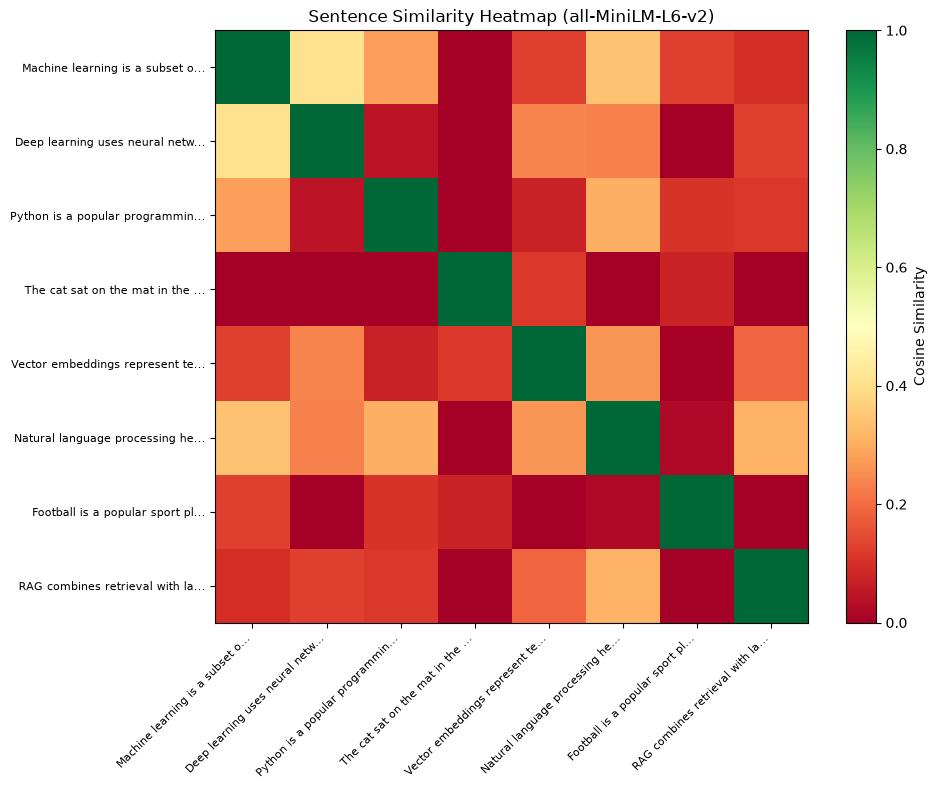

In [6]:
# Similarity heatmap — Similarity b/w sentences
vecs = model_mini.encode(sentences)
n = len(sentences)
sim_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        sim_matrix[i][j] = cosine_sim(vecs[i], vecs[j])

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im, label='Cosine Similarity')

labels = [s[:30] + '...' for s in sentences]
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
ax.set_title('Sentence Similarity Heatmap (all-MiniLM-L6-v2)', fontsize=12)

plt.tight_layout()
plt.savefig('similarity_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()


In [7]:
# Multiple queries test — retrieval accuracy check
test_cases = [
    {
        'query': 'What is machine learning?',
        'expected_top': 'Machine learning is a subset of artificial intelligence'
    },
    {
        'query': 'How does RAG work?',
        'expected_top': 'RAG combines retrieval with language model generation'
    },
    {
        'query': 'Tell me about sports',
        'expected_top': 'Football is a popular sport played worldwide'
    },
]

correct = 0
print('Retrieval Accuracy Test')
print('=' * 50)
for test in test_cases:
    qvec = model_mini.encode([test['query']])[0]
    sims = [(s, cosine_sim(qvec, v)) for s, v in zip(sentences, sent_vecs)]
    top_result = max(sims, key=lambda x: x[1])[0]
    passed = top_result == test['expected_top']
    if passed:
        correct += 1
    status = 'PASS' if passed else 'FAIL'
    print(f'[{status}] Query: {test["query"]}')
    print(f'       Top result: {top_result[:60]}')

print(f'\nAccuracy: {correct}/{len(test_cases)} = {correct/len(test_cases)*100:.0f}%')

Retrieval Accuracy Test
[PASS] Query: What is machine learning?
       Top result: Machine learning is a subset of artificial intelligence
[PASS] Query: How does RAG work?
       Top result: RAG combines retrieval with language model generation
[PASS] Query: Tell me about sports
       Top result: Football is a popular sport played worldwide

Accuracy: 3/3 = 100%


In [8]:
print('=' * 50)
print('CONCLUSION')
print('=' * 50)
print()
print('all-MiniLM-L6-v2:')
print('  Dimension : 384')
print('  Model size: ~90MB')
print('  Speed     : Fast (CPU pe bhi)')
print('  Accuracy  : Good for most use cases')
print()
print('RECOMMENDATION: all-MiniLM-L6-v2 use karo')
print('Reason: Best speed/accuracy balance for local deployment')

CONCLUSION

all-MiniLM-L6-v2:
  Dimension : 384
  Model size: ~90MB
  Speed     : Fast (CPU pe bhi)
  Accuracy  : Good for most use cases

RECOMMENDATION: all-MiniLM-L6-v2 use karo
Reason: Best speed/accuracy balance for local deployment
